# Analysing Pharmaceutical Sales Data 

**What the data is:** daily sales of 8 groups of drugs from a pharmacy. Each group has an ATC code (a standard drug classification):

| Code | Drug group |
|---|---|
| M01AB | Acetic acid derivatives (e.g. diclofenac) |
| M01AE | Propionic acid derivatives (e.g. ibuprofen) |
| N02BA | Salicylic acid & derivatives (e.g. aspirin) |
| N02BE | Anilides (e.g. paracetamol) |
| N05B | Anxiolytics |
| N05C | Hypnotics & sedatives |
| R03 | Drugs for obstructive airway diseases (asthma/COPD) |
| R06 | Antihistamines |

## Step 0 — Set up

0.1 Import the libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

0.2 Load the CSV.

In [2]:
df = pd.read_csv("data/salesdaily.csv", parse_dates=["datum"])

0.3 Look at the data before analysing it.

In [3]:
df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


0.4 Check the size and column types.


In [4]:
print(df.shape)
df.info()

(2106, 13)
<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datum         2106 non-null   datetime64[us]
 1   M01AB         2106 non-null   float64       
 2   M01AE         2106 non-null   float64       
 3   N02BA         2106 non-null   float64       
 4   N02BE         2106 non-null   float64       
 5   N05B          2106 non-null   float64       
 6   N05C          2106 non-null   float64       
 7   R03           2106 non-null   float64       
 8   R06           2106 non-null   float64       
 9   Year          2106 non-null   int64         
 10  Month         2106 non-null   int64         
 11  Hour          2106 non-null   int64         
 12  Weekday Name  2106 non-null   str           
dtypes: datetime64[us](1), float64(8), int64(3), str(1)
memory usage: 214.0 KB


**0.5 Tidy up.** Two small things:
1. Rename `datum` to `date`  and `Weekday Name` to `weekday`.
2. Make a list called `codes` with the 8 drug columns. We'll reuse it. 

In [5]:
df = df.rename(columns={"datum": "date", "Weekday Name": "weekday"})

codes = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]

df[codes].describe()

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
count,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000
mean,5.033683,3.895830,3.880441,29.917095,8.853627,0.593522,5.512262,2.900198
std,2.737579,2.133337,2.384010,15.590966,5.605605,1.092988,6.428736,2.415816
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,2.340000,2.000000,19.000000,5.000000,0.000000,1.000000,1.000000
50%,4.990000,3.670000,3.500000,26.900000,8.000000,0.000000,4.000000,2.000000
75%,6.670000,5.138000,5.200000,38.300000,12.000000,1.000000,8.000000,4.000000
max,17.340000,14.463000,16.000000,161.000000,54.833333,9.000000,45.000000,15.000000


`describe()` gives count, mean, min, max for each drug. 

## Question 1 — Total sales quantity for each drug category

1.1 Add up each column and puts the biggest first.

In [6]:
totals = df[codes].sum().sort_values(ascending=False)
totals

N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
dtype: float64

1.2 What share is the biggest one? Divide its total by the grand total of everything.

In [7]:
share = totals["N02BE"] / totals.sum()
print(f"N02BE is {share:.1%} of all units sold")

N02BE is 49.4% of all units sold


1.3 Draw it. A bar chart is right for comparing categories. 

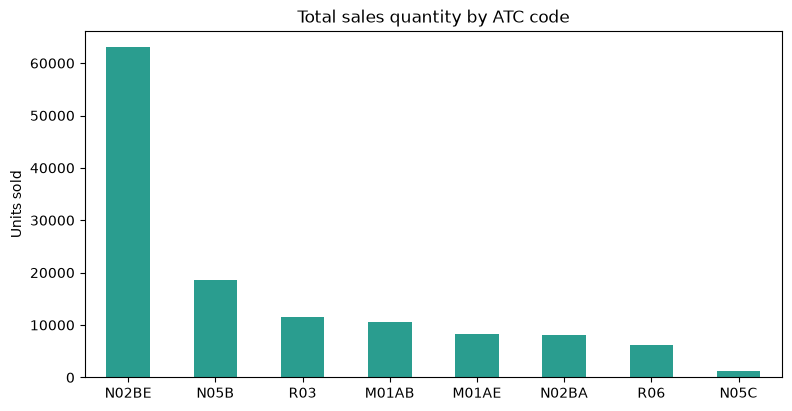

In [8]:
ax = totals.plot(kind="bar", color="#2a9d8f", figsize=(9, 4.5))
ax.set_title("Total sales quantity by ATC code")
ax.set_ylabel("Units sold")
plt.xticks(rotation=0)
plt.show()

## Question 2 — Which individual drugs have the highest total sales?

⚠️ This dataset has no brand names. The sales are already grouped by ATC code. Here it is as a neat table with each drug's share.

In [9]:
ranking = totals.to_frame("total_units")
ranking["share_%"] = (ranking["total_units"] / ranking["total_units"].sum() * 100).round(1)
ranking

,total_units,share_%
N02BE,63005.402708,49.4
N05B,18645.737500,14.6
R03,11608.822917,9.1
M01AB,10600.937083,8.3
M01AE,8204.618646,6.4
N02BA,8172.209000,6.4
R06,6107.817500,4.8
N05C,1249.958333,1.0


## Question 3 — Top 3 drugs in January 2015, July 2016 and September 2017

3.1 Do it for ONE month first (always solve the small case before looping).

`df["date"].dt.year` pulls the year out of each date, `.dt.month` the month. We combine two conditions with `&` and keep only matching rows. Then sum, and `nlargest(3)` gives the top 3.

In [10]:
jan_2015 = df[(df["date"].dt.year == 2015) & (df["date"].dt.month == 1)]

print("Rows in this month:", len(jan_2015))
jan_2015[codes].sum().nlargest(3)

Rows in this month: 31


N02BE    1044.24
N05B      463.00
R03       177.25
dtype: float64

**3.2 Now repeat for all three periods** with a loop, and store each result in a dictionary so we can chart it.

In [11]:
periods = [(2015, 1), (2016, 7), (2017, 9)]
top3 = {}

for year, month in periods:
    subset = df[(df["date"].dt.year == year) & (df["date"].dt.month == month)]
    label = f"{month}/{year}"
    top3[label] = subset[codes].sum().nlargest(3)
    print(label)
    print(top3[label].round(1))
    print()

1/2015
N02BE    1044.2
N05B      463.0
R03       177.2
dtype: float64

7/2016
N02BE    652.4
N05B     240.0
M01AB    194.5
dtype: float64

9/2017
N02BE    863.8
N05B     223.0
R03      139.0
dtype: float64



3.3 Chart: three small bar charts side by side.

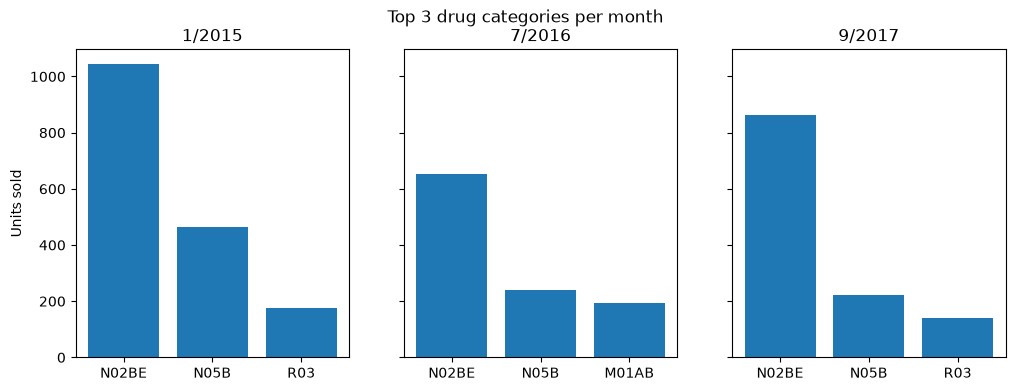

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, (label, s) in zip(axes, top3.items()):
    ax.bar(s.index, s.values)
    ax.set_title(label)

axes[0].set_ylabel("Units sold")
fig.suptitle("Top 3 drug categories per month")
plt.show()

## Question 4 — Which drug has sold the most often in 2017?

**Interpretation:** 'most often' = on the **most days**.

**4.1 Keep only 2017.**

In [13]:
d17 = df[df["date"].dt.year == 2017]
print("Days in 2017:", len(d17))

Days in 2017: 365


**4.2 Count days with a sale.** 

In [14]:
days_sold = (d17[codes] > 0).sum().sort_values(ascending=False)
days_sold

N02BE    361
M01AB    360
M01AE    360
N05B     356
N02BA    350
R06      329
R03      286
N05C      99
dtype: int64

Look at the top of that list: several drugs are within a day or two of each other. **When it's nearly a tie, say so** also check total volume in 2017:

In [15]:
d17[codes].sum().sort_values(ascending=False)

N02BE    9258.804833
N05B     2555.541667
R03      1893.614583
M01AB    1846.617083
M01AE    1387.298333
N02BA    1288.295833
R06       988.860000
N05C      180.333333
dtype: float64

**4.3 Chart it.** The dashed line marks 365 = sold every single day.

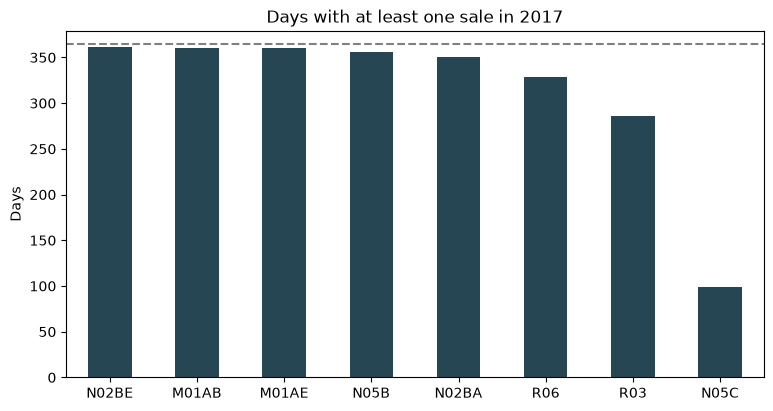

In [16]:
ax = days_sold.plot(kind="bar", color="#264653", figsize=(9, 4.5))
ax.axhline(len(d17), linestyle="--", color="grey")
ax.set_title("Days with at least one sale in 2017")
ax.set_ylabel("Days")
plt.xticks(rotation=0)
plt.show()

## Question 5 — Which category has the highest average daily sales?

`mean()` instead of `sum()`. *units per day*.

In [17]:
avg_daily = df[codes].mean().sort_values(ascending=False)
avg_daily.round(2)

N02BE    29.92
N05B      8.85
R03       5.51
M01AB     5.03
M01AE     3.90
N02BA     3.88
R06       2.90
N05C      0.59
dtype: float64

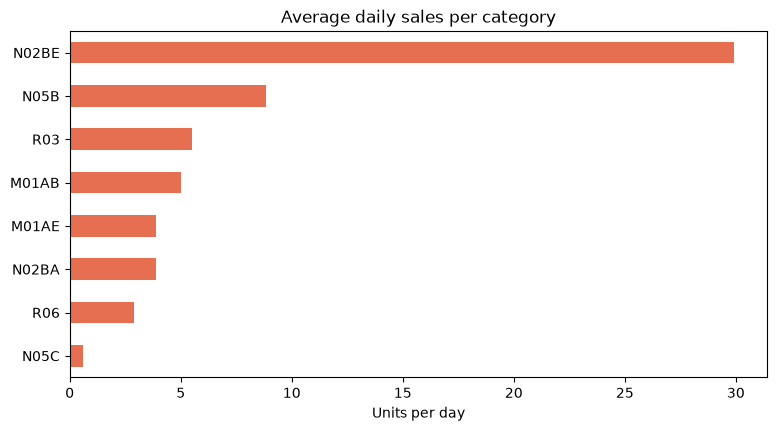

In [18]:
ax = avg_daily.sort_values().plot(kind="barh", color="#e76f51", figsize=(9, 4.5))
ax.set_title("Average daily sales per category")
ax.set_xlabel("Units per day")
plt.show()

## Question 6 — Are respiratory drugs (R03) sold more in specific months?

**6.1 Average R03 per calendar month.** `groupby(month)` splits the rows into 12 groups (all Januaries together, all Februaries...) and `.mean()` averages each group.



In [19]:
r03_by_month = df.groupby(df["date"].dt.month)["R03"].mean()
r03_by_month.index = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
r03_by_month.round(2)

Jan    6.84
Feb    6.90
Mar    6.29
Apr    5.77
May    5.01
Jun    4.35
Jul    2.96
Aug    3.10
Sep    4.40
Oct    7.21
Nov    6.23
Dec    7.92
Name: R03, dtype: float64

In [20]:
peak, low = r03_by_month.idxmax(), r03_by_month.idxmin()
print(f"Peak: {peak} ({r03_by_month.max():.1f}/day)")
print(f"Low:  {low} ({r03_by_month.min():.1f}/day)")
print(f"Peak is {r03_by_month.max() / r03_by_month.min():.1f}x the low")

Peak: Dec (7.9/day)
Low:  Jul (3.0/day)
Peak is 2.7x the low


**6.2 Chart.** Months above the yearly average are coloured red, below are blue.

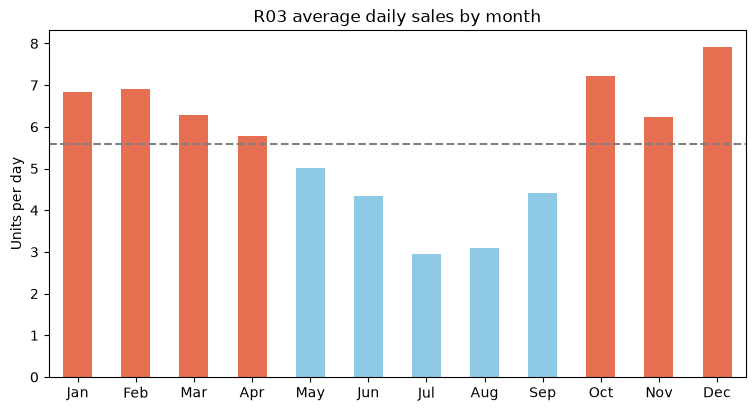

In [21]:
avg = r03_by_month.mean()
colors = ["#e76f51" if v > avg else "#8ecae6" for v in r03_by_month]

ax = r03_by_month.plot(kind="bar", color=colors, figsize=(9, 4.5))
ax.axhline(avg, linestyle="--", color="grey")
ax.set_title("R03 average daily sales by month")
ax.set_ylabel("Units per day")
plt.xticks(rotation=0)
plt.show()

**6.3 Is it a real pattern or a fluke?** Check it year by year. If the same months are dark every year.

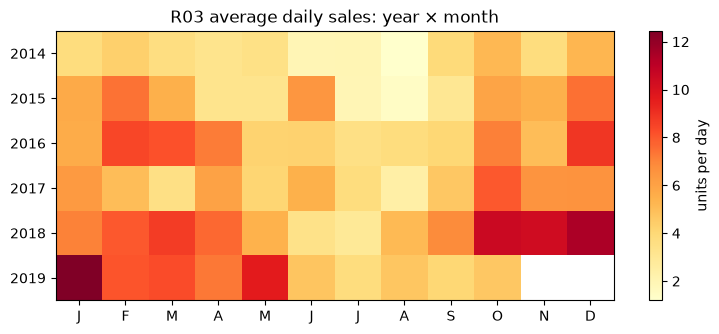

In [22]:
heat = df.groupby([df["date"].dt.year, df["date"].dt.month])["R03"].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 3.5))
im = ax.imshow(heat, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(12))
ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax.set_yticks(range(len(heat)))
ax.set_yticklabels(heat.index)
fig.colorbar(im, label="units per day")
ax.set_title("R03 average daily sales: year × month")
plt.show()

## Your findings (fill these in yourself)

Write one sentence per question in your own words. This is the part employers and LinkedIn readers actually care about.

1. Total by category: ...
2. Highest-selling drug: ...
3. Top 3 in the three months: ...
4. Sold most often in 2017: ...
5. Highest average daily sales: ...
6. R03 seasonality: ...

## Bonus — Save a chart as an image for LinkedIn / TikTok

Add `plt.savefig(...)` **before** `plt.show()`. `dpi=200` makes it sharp and `bbox_inches='tight'` trims the white border. Run this cell, then find `r03_seasonality.png` in your folder.

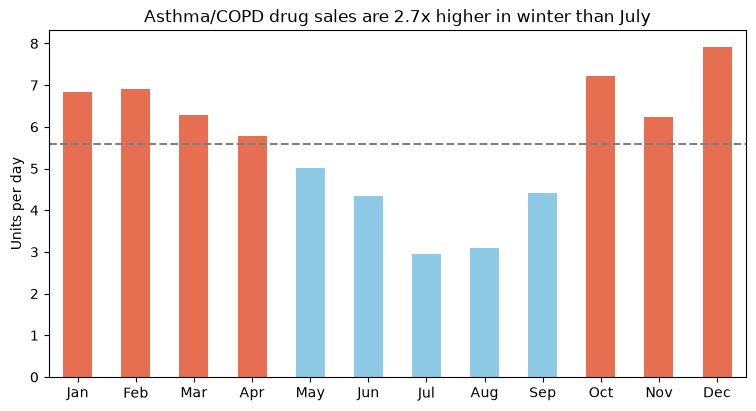

In [23]:
ax = r03_by_month.plot(kind="bar", color=colors, figsize=(9, 4.5))
ax.axhline(avg, linestyle="--", color="grey")
ax.set_title("Asthma/COPD drug sales are 2.7x higher in winter than July")
ax.set_ylabel("Units per day")
plt.xticks(rotation=0)
plt.savefig("r03_seasonality.png", dpi=200, bbox_inches="tight")
plt.show()